# SHAP Analysis

SHAP (SHapley Additive exPlanations) analyses to quantify local and global predictor contributions to modeled burn severity (Lundberg & Lee, 2017; Lundberg et al., 2020). See [shap.TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html).

In [1]:
import joblib
import shap
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

import rasterio
from rasterio import features
from rasterio.mask import mask as rio_mask
from rasterio.warp import transform_geom
import rasterio.features as rio_features

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import warnings, random
warnings.filterwarnings("ignore", category=FutureWarning)

mpl.rcParams["font.family"] = "Arial"

# Apply the Tree SHAP algorithm to explain the output of the RFR

In [2]:
# Load the trained mode
rf = joblib.load("/Users/megan/Desktop/runmodel/reduced_rf_tuned_20251023.pkl")

# Load the fitted scaler
scaler = joblib.load("/Users/megan/Desktop/runmodel/scaler_allfires.joblib")

# Load the full predictions dataset
df_full = pd.read_parquet("/Users/megan/Desktop/runmodel/reduced_rf_predictions_20251023.parquet")

# Define the variables
reduced_vars_final = [
    "CWC_20240625",
    "ESI_20241201_1049am",
    "ESI_20240625_1038am",
    "WUE_20230409_1028am",
    "WindGust_max_20250108",
    "Elevation",
    "cosAspect",
]

# Recover the scaler’s feature order
continuous_vars = list(scaler.feature_names_in_)

# Build a name to column index lookup
scaler_feature_index = {v: i for i, v in enumerate(continuous_vars)}

# Create a “full-width” placeholder array
# 2D array with: rows = number of samples in df_full, cols = number of features the scaler expects
dummy = np.zeros((len(df_full), len(continuous_vars)))

# Fill only the columns defined above
for v in reduced_vars_final:
    dummy[:, scaler_feature_index[v]] = df_full[v].values

# Inverse-transform back to original units
dummy_unscaled = scaler.inverse_transform(dummy)

# Extract only selected variables into a DataFrame
X_full_unscaled = pd.DataFrame(
    {v: dummy_unscaled[:, scaler_feature_index[v]] for v in reduced_vars_final},
    index=df_full.index
)

In [3]:
# Select the scaled predictor values
X_all_scaled = df_full[reduced_vars_final]

# Initialize the SHAP explainer
## Create a SHAP explainer object specifically optimized for tree-based models; this uses the trained Random Forest rf to learn how predictions are constructed from splits across trees.
explainer = shap.TreeExplainer(rf)

# Compute SHAP values for all samples
shap_values_all = explainer.shap_values(X_all_scaled)  # all ~48k rows

In [4]:
# Check SHAP array dimensions
shap_values_all.shape

# Check unscaled predictor dimensions
X_full_unscaled.shape

(48250, 7)

In [5]:
# Inspect scaled/unscaled Elevation distribution
print(X_all_scaled["Elevation"].describe())
print(X_full_unscaled["Elevation"].describe())

count    48250.000000
mean         0.033073
std          0.989230
min         -1.797646
25%         -0.599997
50%         -0.154133
75%          0.392620
max          3.764262
Name: Elevation, dtype: float64
count    48250.000000
mean       574.522653
std        303.959385
min         12.000000
25%        380.000000
50%        517.000000
75%        685.000000
max       1721.000000
Name: Elevation, dtype: float64


# Figures

## SHAP summary (beeswarm)

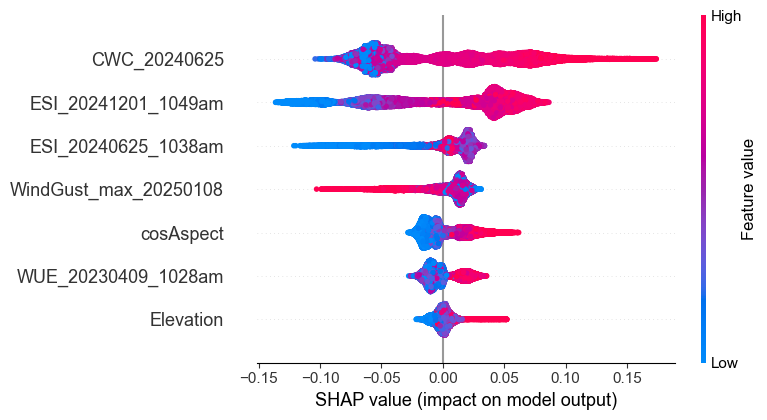

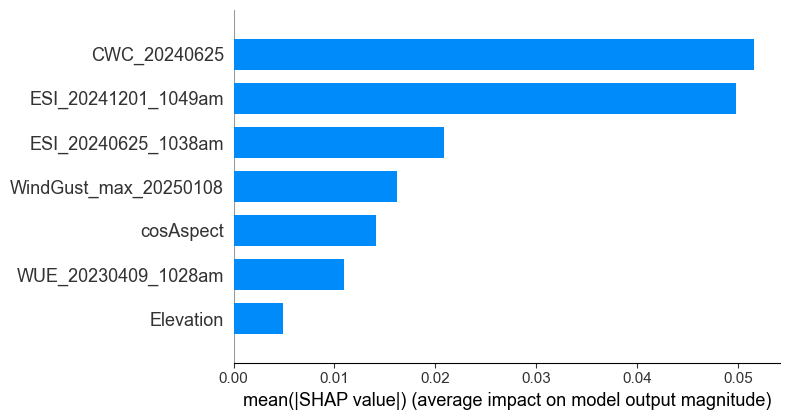

,Mean SHAP,Mean |SHAP|,Frac Positive,Frac Negative
CWC_20240625,-0.000216,0.051604,0.480394,0.519606
ESI_20241201_1049am,0.002606,0.049800,0.592725,0.407275
ESI_20240625_1038am,0.002350,0.020896,0.747606,0.252394
WindGust_max_20250108,0.001968,0.016175,0.684311,0.315689
cosAspect,0.000394,0.014108,0.383316,0.616684
WUE_20230409_1028am,-0.000914,0.010972,0.324684,0.675316
Elevation,-0.000146,0.004853,0.498238,0.501762


In [6]:
# Vertical order → global importance (mean |SHAP|)
# Horizontal position → direction & magnitude
# Color (feature value) → why the direction happens

plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values_all,
    X_full_unscaled,
    feature_names=reduced_vars_final,
    show=False  
)

plt.tight_layout()
plt.savefig(
    "/Users/megan/Desktop/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Global SHAP importance

plt.figure(figsize=(6, 4))

shap.summary_plot(
    shap_values_all,
    X_full_unscaled,
    plot_type="bar",
    feature_names=reduced_vars_final,
    show=False
)

plt.tight_layout()
plt.savefig(
    "/Users/megan/Desktop/shap_importance_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

shap_importance = pd.DataFrame({
    "Feature": reduced_vars_final,
    "Mean |SHAP|": np.abs(shap_values_all).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False)

shap_importance

shap_df = pd.DataFrame(
    shap_values_all,
    columns=reduced_vars_final,
    index=df_full.index
)

summary = pd.DataFrame({
    "Mean SHAP": shap_df.mean(),
    "Mean |SHAP|": shap_df.abs().mean(),
    "Frac Positive": (shap_df > 0).mean(),
    "Frac Negative": (shap_df < 0).mean()
}).sort_values("Mean |SHAP|", ascending=False)

summary

## SHAP dependence plot for every feature

SHAP dependence plot for: CWC_20240625


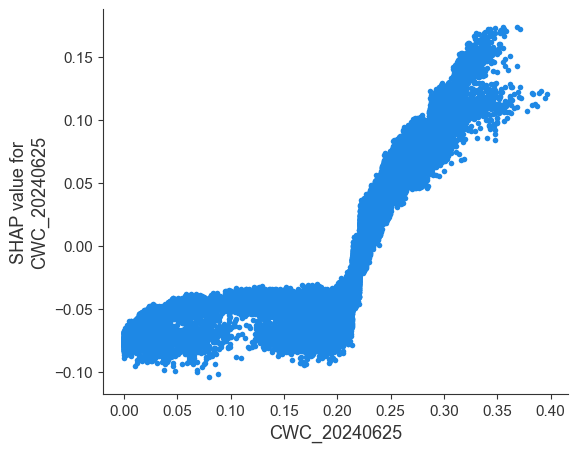

SHAP dependence plot for: ESI_20241201_1049am


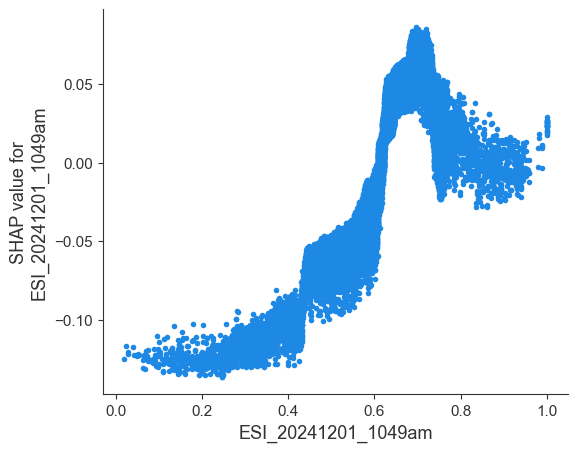

SHAP dependence plot for: ESI_20240625_1038am


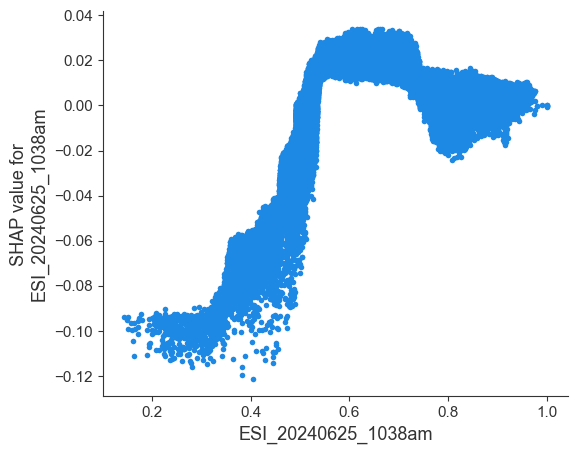

SHAP dependence plot for: WUE_20230409_1028am


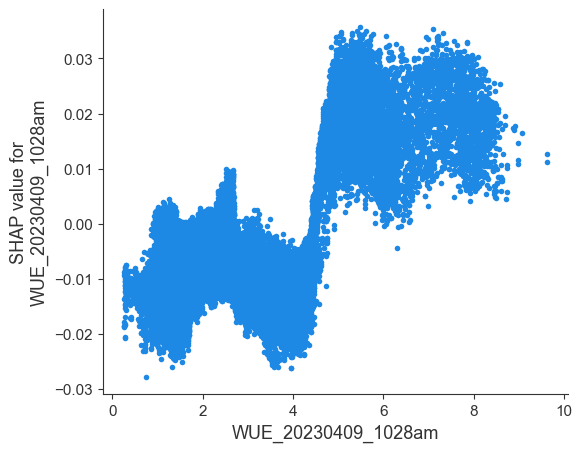

SHAP dependence plot for: WindGust_max_20250108


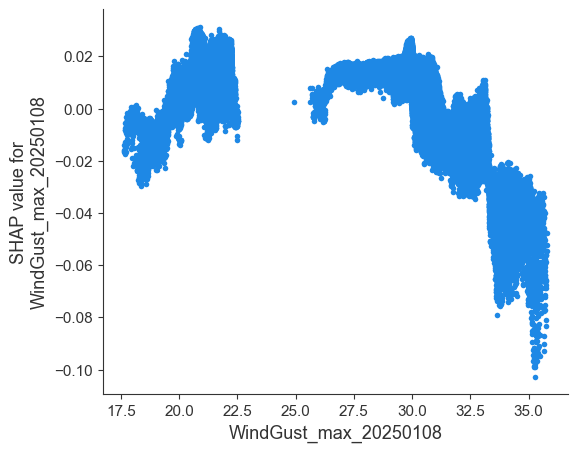

SHAP dependence plot for: Elevation


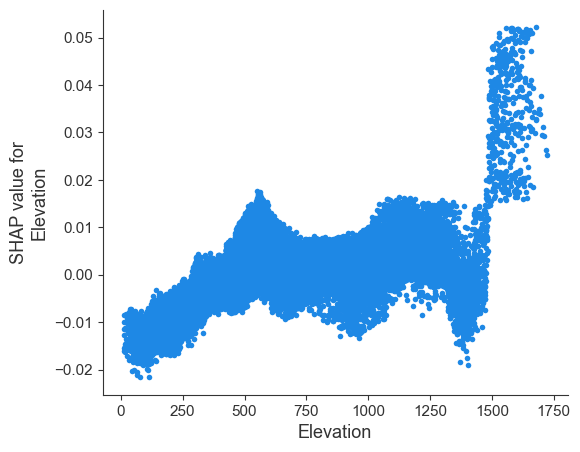

SHAP dependence plot for: cosAspect


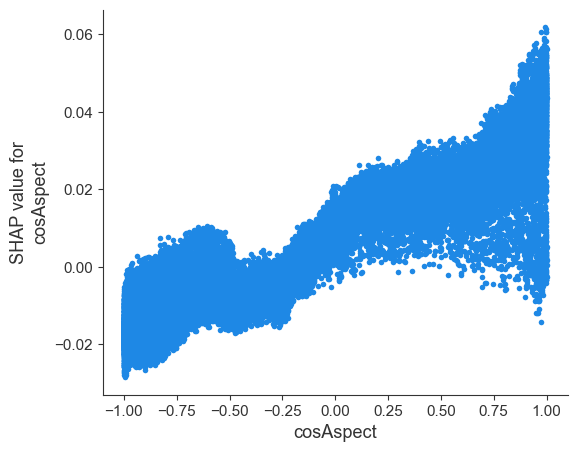

In [7]:
# List of features
features = [
    "CWC_20240625",
    "ESI_20241201_1049am",
    "ESI_20240625_1038am",
    "WUE_20230409_1028am",
    "WindGust_max_20250108",
    "Elevation",
    "cosAspect",
]

# Loop through all features and plot SHAP dependence
for feat in features:
    print(f"SHAP dependence plot for: {feat}")
    
    shap.dependence_plot(
        feat,
        shap_values_all,
        X_full_unscaled,      # original units
        interaction_index=None,
        show=True
    )

## Local SHAP importance maps

In [8]:
# check ranges
pd.DataFrame({
    "min": np.nanmin(shap_values_all, axis=0),
    "max": np.nanmax(shap_values_all, axis=0),
}, index=reduced_vars_final)

,min,max
CWC_20240625,-0.104020,0.173885
ESI_20241201_1049am,-0.136259,0.086466
ESI_20240625_1038am,-0.121352,0.033928
WUE_20230409_1028am,-0.027816,0.035720
WindGust_max_20250108,-0.102851,0.031249
Elevation,-0.021613,0.052176
cosAspect,-0.028460,0.061810


In [9]:
wildfire_rasters = {
    "Eaton": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Eaton_WFIGS_Interagency_Perimeters_YearToDate_-8396875942426194654/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/Eaton_LayerStack_updated20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/NLCD_Eaton_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/NLCD_Eaton_resampled.tif"
    },
    "Hughes": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Hughes_WFIGS_Interagency_Perimeters_YearToDate_7148479240675437113/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/Hughes_layerstack_updated_20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/NLCD_Hughes_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/NLCD_Hughes_resampled.tif"
    },
    "Palisades": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Palisades_WFIGS_Interagency_Perimeters_YearToDate_2024716492027912883/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/Palisades_LayerStack_updated20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/NLCD_Palisades_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/NLCD_Palisades_resampled.tif"
    }
}

feature_rename = {
    "CWC_20240625": "CWC (Jun 2024)",
    "ESI_20241201_1049am": "ESI (Dec 2024)",
    "ESI_20240625_1038am": "ESI (Jun 2024)",
    "WUE_20230409_1028am": "WUE (Apr 2023)",
    "WindGust_max_20250108": "Wind Gust (Max)",
    "Elevation": "Elevation",
    "cosAspect": "Aspect (Northness)",
}


def _read_perimeter_union(perim_path, target_crs="OGC:CRS84"):
    gdf = gpd.read_file(perim_path)
    if gdf.crs is None:
        raise ValueError(f"Perimeter has no CRS: {perim_path}")
    gdf = gdf.to_crs(target_crs)
    return gdf.unary_union  # shapely geometry


def _crop_template_to_perimeter(template_path, perim_geom_crs84):
    """
    Crop template raster (mask.tif) to perimeter; return:
      - template_meta: (crs, transform, height, width, nodata)
      - template_vals: cropped template band values
      - outside_perim_mask: boolean mask True where outside crop/perimeter (set to NaN)
    """
    with rasterio.open(template_path) as src:
        # Reproject perimeter to src CRS if needed
        if src.crs and src.crs.to_string() != "OGC:CRS84":
            geom_in_src = transform_geom(
                "OGC:CRS84", src.crs, perim_geom_crs84.__geo_interface__
            )
        else:
            geom_in_src = perim_geom_crs84.__geo_interface__

        out_img, out_transform = rio_mask(src, [geom_in_src], crop=True, filled=False)

        # out_img is MaskedArray if filled=False
        if hasattr(out_img, "mask"):
            outside_perim_mask = out_img.mask[0]
            template_vals = out_img.data[0]
        else:
            template_vals = out_img[0]
            outside_perim_mask = np.zeros_like(template_vals, dtype=bool)

        meta = {
            "crs": src.crs,
            "transform": out_transform,
            "height": template_vals.shape[0],
            "width": template_vals.shape[1],
            "nodata": src.nodata,
        }
        return meta, template_vals, outside_perim_mask


def _rasterize_points_to_grid(gdf_pts, value_col, transform, out_shape, fill=np.nan, dtype="float32"):
    shapes = (
        (geom, val)
        for geom, val in zip(gdf_pts.geometry, gdf_pts[value_col])
        if pd.notnull(val)
    )
    return rio_features.rasterize(
        shapes=shapes,
        out_shape=out_shape,
        transform=transform,
        fill=fill,
        dtype=dtype
    )



def plot_shap_maps_mask_template(
    fire_name,
    wildfire_rasters,
    df_full,
    shap_values_all,
    reduced_vars_final,
    xcol="X",
    ycol="Y",
    out_dir=None,
    save_each_feature=True,
    apply_mask_values=True,
    breaks=None,
):
    perim_path = wildfire_rasters[fire_name]["burn_perimeter"]
    template_path = wildfire_rasters[fire_name]["mask"]  # use mask.tif as template grid

    # 1) perimeter geom (CRS84 to match X/Y lon/lat)
    perim_geom_crs84 = _read_perimeter_union(perim_path, target_crs="OGC:CRS84")

    # 2) crop template to perimeter
    template_meta, template_vals, outside_perim_mask = _crop_template_to_perimeter(template_path, perim_geom_crs84)
    out_shape = (template_meta["height"], template_meta["width"])
    out_transform = template_meta["transform"]

    # 3) points GeoDataFrame (CRS84)
    gdf_pts = gpd.GeoDataFrame(
        df_full[[xcol, ycol]].copy(),
        geometry=[Point(xy) for xy in zip(df_full[xcol].values, df_full[ycol].values)],
        crs="OGC:CRS84"
    )

    # 4) attach SHAP values per feature
    shap_df = pd.DataFrame(shap_values_all, columns=reduced_vars_final, index=df_full.index)
    gdf_pts = gdf_pts.join(shap_df)

    # Reproject points to template CRS if needed
    if template_meta["crs"] and template_meta["crs"].to_string() != "OGC:CRS84":
        gdf_pts = gdf_pts.to_crs(template_meta["crs"])

    # 5) breaks / colormap
    if breaks is None:
        # bins
        breaks = [-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15]

    norm = mcolors.BoundaryNorm(breaks, ncolors=256, clip=True)
    cmap = plt.get_cmap("coolwarm")

    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    rasters = {}

    for feat in reduced_vars_final:
        r = _rasterize_points_to_grid(gdf_pts, feat, out_transform, out_shape, fill=np.nan).astype("float32")

        # mask outside perimeter crop
        r[outside_perim_mask] = np.nan

        # apply mask raster values too (0 or nodata => drop)
        if apply_mask_values:
            drop = (template_vals == 0)
            if template_meta["nodata"] is not None:
                drop |= (template_vals == template_meta["nodata"])
            r[drop] = np.nan

        rasters[feat] = r

        title = feature_rename.get(feat, feat)

        # plot once; save same figure if requested
        fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=200)
        im = ax.imshow(r, cmap=cmap, norm=norm)
        ax.set_title(f"{fire_name} — {title}", fontsize=10)
        ax.axis("off")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("SHAP value", fontsize=9)

        plt.tight_layout()

        if save_each_feature and out_dir:
            fig.savefig(os.path.join(out_dir, f"{fire_name}_shap_{feat}.png"), bbox_inches="tight")
            plt.close(fig)
        else:
            plt.show()

    return rasters, template_meta


# Run
out_dir = "/Users/megan/Desktop/shap_maps_final_"

# build once outside the loop
shap_df = pd.DataFrame(
    shap_values_all,
    columns=reduced_vars_final,
    index=df_full.index
)

for fire_name in wildfire_rasters:
    df_fire = df_full[df_full["Fire"] == fire_name].copy()

    # subset SHAP to the same rows, then convert back to array 
    shap_values_fire = shap_df.loc[df_fire.index, reduced_vars_final].to_numpy()

    rasters, meta = plot_shap_maps_mask_template(
        fire_name=fire_name,
        wildfire_rasters=wildfire_rasters,
        df_full=df_fire,                      
        shap_values_all=shap_values_fire,   
        reduced_vars_final=reduced_vars_final,
        xcol="X",
        ycol="Y",
        out_dir=out_dir,
        save_each_feature=True,
        apply_mask_values=True,
        breaks = [-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15],  
    )


/var/folders/br/pyt6szbd2wb4q6n5wqkffrbc0000gn/T/ipykernel_21227/4113968073.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return gdf.unary_union  # shapely geometry
/var/folders/br/pyt6szbd2wb4q6n5wqkffrbc0000gn/T/ipykernel_21227/4113968073.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return gdf.unary_union  # shapely geometry
/var/folders/br/pyt6szbd2wb4q6n5wqkffrbc0000gn/T/ipykernel_21227/4113968073.py:38: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return gdf.unary_union  # shapely geometry


In [10]:
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

import rasterio
from rasterio import features
from rasterio.mask import mask as rio_mask
from rasterio.warp import transform_geom

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"


wildfire_rasters = {
    "Eaton": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Eaton_WFIGS_Interagency_Perimeters_YearToDate_-8396875942426194654/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/Eaton_LayerStack_updated20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/NLCD_Eaton_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/NLCD_Eaton_resampled.tif"
    },
    "Hughes": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Hughes_WFIGS_Interagency_Perimeters_YearToDate_7148479240675437113/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/Hughes_layerstack_updated_20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/NLCD_Hughes_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/NLCD_Hughes_resampled.tif"
    },
    "Palisades": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Palisades_WFIGS_Interagency_Perimeters_YearToDate_2024716492027912883/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/Palisades_LayerStack_updated20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/NLCD_Palisades_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/NLCD_Palisades_resampled.tif"
    }
}

feature_rename = {
    "CWC_20240625": "CWC (Jun 2024)",
    "ESI_20241201_1049am": "ESI (Dec 2024)",
    "ESI_20240625_1038am": "ESI (Jun 2024)",
    "WUE_20230409_1028am": "WUE (Apr 2023)",
    "WindGust_max_20250108": "Wind Gust (Max)",
    "Elevation": "Elevation",
    "cosAspect": "Aspect (Northness)",
}


def _read_perimeter_union(perim_path, target_crs="OGC:CRS84"):
    gdf = gpd.read_file(perim_path)
    if gdf.crs is None:
        raise ValueError(f"Perimeter has no CRS: {perim_path}")
    gdf = gdf.to_crs(target_crs)
    return gdf.unary_union  # shapely geometry


def _crop_template_to_perimeter(template_path, perim_geom_crs84):
    """
    Crop template raster (mask.tif) to perimeter; return:
      - template_meta: (crs, transform, height, width, nodata)
      - template_vals: cropped template band values
      - outside_perim_mask: boolean mask True where outside crop/perimeter (set to NaN)
    """
    with rasterio.open(template_path) as src:
        # Reproject perimeter to src CRS if needed
        if src.crs and src.crs.to_string() != "OGC:CRS84":
            geom_in_src = transform_geom(
                "OGC:CRS84", src.crs, perim_geom_crs84.__geo_interface__
            )
        else:
            geom_in_src = perim_geom_crs84.__geo_interface__

        out_img, out_transform = rio_mask(src, [geom_in_src], crop=True, filled=False)

        # out_img is MaskedArray if filled=False
        if hasattr(out_img, "mask"):
            outside_perim_mask = out_img.mask[0]
            template_vals = out_img.data[0]
        else:
            template_vals = out_img[0]
            outside_perim_mask = np.zeros_like(template_vals, dtype=bool)

        meta = {
            "crs": src.crs,
            "transform": out_transform,
            "height": template_vals.shape[0],
            "width": template_vals.shape[1],
            "nodata": src.nodata,
        }
        return meta, template_vals, outside_perim_mask


def _rasterize_points_to_grid(gdf_pts, value_col, transform, out_shape, fill=np.nan, dtype="float32"):
    shapes = (
        (geom, val)
        for geom, val in zip(gdf_pts.geometry, gdf_pts[value_col])
        if pd.notnull(val)
    )
    return features.rasterize(
        shapes=shapes,
        out_shape=out_shape,
        transform=transform,
        fill=fill,
        dtype=dtype
    )


def plot_shap_maps_mask_template(
    fire_name,
    wildfire_rasters,
    df_full,
    shap_values_all,
    reduced_vars_final,
    xcol="X",
    ycol="Y",
    out_dir=None,
    save_each_feature=True,
    apply_mask_values=True,
    breaks=None,
):
    perim_path = wildfire_rasters[fire_name]["burn_perimeter"]
    template_path = wildfire_rasters[fire_name]["mask"]  # use mask.tif as template grid

    # 1) perimeter geom (CRS84 to match X/Y lon/lat)
    perim_geom_crs84 = _read_perimeter_union(perim_path, target_crs="OGC:CRS84")

    # 2) crop template to perimeter
    template_meta, template_vals, outside_perim_mask = _crop_template_to_perimeter(template_path, perim_geom_crs84)
    out_shape = (template_meta["height"], template_meta["width"])
    out_transform = template_meta["transform"]

    # 3) points GeoDataFrame (CRS84)
    gdf_pts = gpd.GeoDataFrame(
        df_full[[xcol, ycol]].copy(),
        geometry=[Point(xy) for xy in zip(df_full[xcol].values, df_full[ycol].values)],
        crs="OGC:CRS84"
    )

    # 4) attach SHAP values per feature
    shap_df = pd.DataFrame(shap_values_all, columns=reduced_vars_final, index=df_full.index)
    gdf_pts = gdf_pts.join(shap_df)

    # Reproject points to template CRS if needed
    if template_meta["crs"] and template_meta["crs"].to_string() != "OGC:CRS84":
        gdf_pts = gdf_pts.to_crs(template_meta["crs"])

    # 5) breaks / colormap
    if breaks is None:
        # bins
        breaks = [-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15]

    norm = mcolors.BoundaryNorm(breaks, ncolors=256, clip=True)
    cmap = plt.get_cmap("coolwarm")

    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    rasters = {}

    for feat in reduced_vars_final:
        r = _rasterize_points_to_grid(gdf_pts, feat, out_transform, out_shape, fill=np.nan).astype("float32")

        # mask outside perimeter crop
        r[outside_perim_mask] = np.nan

        # apply mask raster values too (0 or nodata => drop)
        if apply_mask_values:
            drop = (template_vals == 0)
            if template_meta["nodata"] is not None:
                drop |= (template_vals == template_meta["nodata"])
            r[drop] = np.nan

        rasters[feat] = r

        title = feature_rename.get(feat, feat)

        # plot once; save same figure if requested
        fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=200)
        im = ax.imshow(r, cmap=cmap, norm=norm)
        ax.set_title(f"{title}", fontsize=18)
        ax.axis("off")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("SHAP value", fontsize=12)

        plt.tight_layout()

        if save_each_feature and out_dir:
            fig.savefig(os.path.join(out_dir, f"{fire_name}_shap_{feat}.png"), bbox_inches="tight")
            plt.close(fig)
        else:
            plt.show()

    return rasters, template_meta


# Run
out_dir = "/Users/megan/Desktop/runmodel/shap_maps"

# build once outside the loop
shap_df = pd.DataFrame(
    shap_values_all,
    columns=reduced_vars_final,
    index=df_full.index
)

for fire_name in wildfire_rasters:
    df_fire = df_full[df_full["Fire"] == fire_name].copy()

    # subset SHAP to the same rows, then convert back to array 
    shap_values_fire = shap_df.loc[df_fire.index, reduced_vars_final].to_numpy()

    rasters, meta = plot_shap_maps_mask_template(
        fire_name=fire_name,
        wildfire_rasters=wildfire_rasters,
        df_full=df_fire,                       
        shap_values_all=shap_values_fire,       
        reduced_vars_final=reduced_vars_final,
        xcol="X",
        ycol="Y",
        out_dir=out_dir,
        save_each_feature=True,
        apply_mask_values=True,
        breaks = [-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15],  
    )


/var/folders/br/pyt6szbd2wb4q6n5wqkffrbc0000gn/T/ipykernel_21227/3326030854.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return gdf.unary_union  # shapely geometry
/var/folders/br/pyt6szbd2wb4q6n5wqkffrbc0000gn/T/ipykernel_21227/3326030854.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return gdf.unary_union  # shapely geometry
/var/folders/br/pyt6szbd2wb4q6n5wqkffrbc0000gn/T/ipykernel_21227/3326030854.py:57: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return gdf.unary_union  # shapely geometry
